In [1]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X_digits, y_digits = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits)
n_instances = 50
log_reg = LogisticRegression()
log_reg.fit(X_train[:n_instances], y_train[:n_instances])
log_reg.score(X_test[:n_instances], y_test[:n_instances])

0.76

In [38]:
load_digits()

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 'target': array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7'

In [7]:
X_train.shape


(1347, 64)

In [31]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=50)
X_train_dist = kmeans.fit_transform(X_train)
X_train_dist

array([[33.76293062, 32.62655701, 44.51458935, ..., 36.28795944,
        47.19395651, 51.18942413],
       [46.45566739, 47.84306521, 46.4700286 , ..., 25.00271985,
        44.58581087, 51.14475256],
       [23.81921155, 43.04291141, 38.77232706, ..., 45.95145264,
        47.49888979, 57.90817855],
       ...,
       [42.91063482, 48.75816741, 49.43420025, ..., 37.52727008,
        50.26698252, 58.68986284],
       [34.4467799 , 38.52824361, 52.00547991, ..., 40.96359359,
        43.93483278, 53.21586767],
       [45.49583462, 43.46138772, 47.03027256, ..., 47.13996182,
        48.53240702, 53.35661694]], shape=(1347, 50))

In [10]:
import numpy as np
representative_index_idx = np.argmin(X_train_dist, axis = 0)
representative_index_idx 

array([ 918,   42,  140,  567,  605,  405,  790, 1010,  294,  325,  624,
        640,   24,   25, 1183, 1278,  926, 1079,  282,  371,  441, 1015,
        374,  680,  245,  210,  515,  269,  319,  651,  791,  649, 1127,
        155,  362,   98, 1131, 1265, 1063,  813,  309,  748,  240, 1200,
        291,  234,  211,  436,  668,   69])

In [11]:
representative_index_idx.shape

(50,)

In [13]:
X_train_representative = X_train[representative_index_idx]

In [47]:
y_train_representaive = y_train[representative_index_idx]
y_train_representaive

array([6, 8, 5, 8, 3, 3, 2, 4, 7, 1, 0, 5, 7, 4, 4, 4, 9, 5, 7, 2, 1, 7,
       1, 7, 6, 4, 1, 5, 2, 3, 6, 5, 1, 9, 5, 8, 2, 6, 2, 2, 0, 9, 8, 2,
       9, 1, 8, 3, 4, 9])

In [15]:
X_train_representative

array([[ 0.,  0.,  1., ..., 12.,  4.,  0.],
       [ 0.,  0.,  2., ..., 14.,  1.,  0.],
       [ 0.,  0.,  7., ..., 15.,  2.,  0.],
       ...,
       [ 0.,  2., 14., ...,  2.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  9., ...,  7.,  0.,  0.]], shape=(50, 64))

In [ ]:
import matplotlib.pyplot as plt
def draw_image(index):
    for i in index:
        representative_data = X_train[i].reshape(8,-1)
        representative_label = y_train[i]
        plt.imshow(representative_data, cmap='binary')
        print(representative_label)
        plt.axis('off')
         

6


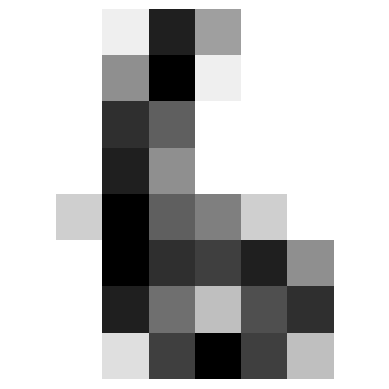

In [51]:
draw_image(representative_index_idx)

In [52]:
representative_labels = y_train[representative_index_idx]
representative_labels

array([6, 8, 5, 8, 3, 3, 2, 4, 7, 1, 0, 5, 7, 4, 4, 4, 9, 5, 7, 2, 1, 7,
       1, 7, 6, 4, 1, 5, 2, 3, 6, 5, 1, 9, 5, 8, 2, 6, 2, 2, 0, 9, 8, 2,
       9, 1, 8, 3, 4, 9])

In [53]:
len(representative_labels)

50

In [54]:
log_reg = LogisticRegression()
log_reg.fit(X_train_representative, representative_labels)
log_reg.score(X_test, y_test)

0.8911111111111111

In [55]:
kmeans.labels_

array([41, 33, 15, ...,  7, 19, 36], shape=(1347,), dtype=int32)

In [57]:
y_train_propogative = np.empty(len(X_train), dtype=np.int32)
for i in range(50):
    y_train_propogative[kmeans.labels_ == i] = representative_labels[i]

In [64]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train_propogative)

,steps,"[('scaler', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [65]:
pipeline.score(X_test, y_test)

0.08222222222222222